# Dự đoán bệnh gan dựa trên kết quả xét nghiệm
**Mục tiêu**: *Dựa vào các chỉ số trong kết quả xét nghiệm máu mà đưa ra dự đoán một người có bị bệnh gan hay không*


Nội dung notebook:
1. Đọc dữ liệu
2. Quan sát dữ liệu 
3. Tiền xử lý dữ liệu
4. Chia dữ liệu train, dữ liệu test
5. Tìm thuộc tính quan trọng dựa trên Random Forest
6. Áp dụng KNN để dự đoán
7. Báo cáo kết quả

#### 1. Đọc dữ liệu

In [53]:
#import thư viện
import pandas as pd
import numpy as np
import os


In [54]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


1. Đọc dữ liệu từ file, in ra số bộ, số thuộc tính

In [55]:
#đọc data
DATA_PATH = "data\Liver_Patient_Dataset_LPD_train.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại {DATA_PATH}. Hãy kiểm tra đường dẫn và upload file vào đúng vị trí.")

df_raw = pd.read_csv(DATA_PATH, encoding='latin1')  # hoặc 'cp1252'

df_raw.shape # in ra số bộ, các thuộc tính

(30691, 11)

In [56]:
def clean_column_names(df):
    """
    Chuẩn hóa tên cột: bỏ khoảng trắng thừa, ký tự đặc biệt
    """
    df_clean = df.copy()
    
    # Mapping từ tên cũ sang tên mới
    column_mapping = {
        'Age of the patient': 'Age of the patient',
        'Gender of the patient': 'Gender of the patient',
        'Total Bilirubin': 'Total Bilirubin',
        'Direct Bilirubin': 'Direct Bilirubin',
        'Alkphos Alkaline Phosphotase': 'Alkphos Alkaline Phosphotase',  # 
        ' Sgpt Alamine Aminotransferase': 'Sgpt Alamine Aminotransferase',  
        'Sgot Aspartate Aminotransferase': 'Sgot Aspartate Aminotransferase',  
        'Total Protiens': 'Total Protiens',
        ' ALB Albumin': 'ALB Albumin',
        'A/G Ratio Albumin and Globulin Ratio': 'A/G Ratio Albumin and Globulin Ratio',
        'Result': 'Result'
    }
    
    print("🔧 CHUẨN HÓA TÊN CỘT:")
    print("-" * 40)
    
    # Đổi tên từng cột
    rename_dict = {}
    for old_name in df_clean.columns:
        # Tìm tên mới trong mapping
        new_name = None
        for key, value in column_mapping.items():
            if key.strip() == old_name.strip():
                new_name = value
                break
        
        # Nếu không tìm thấy, chuẩn hóa chung
        if new_name is None:
            # Chuẩn hóa: chữ thường, thay khoảng trắng bằng _
            new_name = old_name.strip().lower().replace(' ', '_')
            new_name = ''.join(c for c in new_name if c.isalnum() or c == '_')
        
        rename_dict[old_name] = new_name
        print(f"  '{old_name}' → '{new_name}'")
    
    # Áp dụng đổi tên
    df_clean = df_clean.rename(columns=rename_dict)
    
    print(f"\n✅ Đã chuẩn hóa {len(rename_dict)} cột")
    return df_clean

# Sử dụng
df_raw = clean_column_names(df_raw)
print("\nTên cột mới:", df_raw.columns.tolist())

🔧 CHUẨN HÓA TÊN CỘT:
----------------------------------------
  'Age of the patient' → 'Age of the patient'
  'Gender of the patient' → 'Gender of the patient'
  'Total Bilirubin' → 'Total Bilirubin'
  'Direct Bilirubin' → 'Direct Bilirubin'
  ' Alkphos Alkaline Phosphotase' → 'Alkphos Alkaline Phosphotase'
  ' Sgpt Alamine Aminotransferase' → 'Sgpt Alamine Aminotransferase'
  'Sgot Aspartate Aminotransferase' → 'Sgot Aspartate Aminotransferase'
  'Total Protiens' → 'Total Protiens'
  ' ALB Albumin' → 'ALB Albumin'
  'A/G Ratio Albumin and Globulin Ratio' → 'A/G Ratio Albumin and Globulin Ratio'
  'Result' → 'Result'

✅ Đã chuẩn hóa 11 cột

Tên cột mới: ['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', 'Alkphos Alkaline Phosphotase', 'Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']


2. In ra vài dữ liệu đầu tiên

In [57]:
df_raw.head(10) # kết quả 1 là bị gan, 2 là ko bị

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1
5,46.0,Male,1.8,0.7,208.0,19.0,14.0,7.6,4.4,1.30,1
6,26.0,Female,0.9,0.2,154.0,NaN,12.0,7.0,3.5,1.00,1
7,29.0,Female,0.9,0.3,202.0,14.0,11.0,6.7,3.6,1.10,1
8,17.0,Male,0.9,0.3,202.0,22.0,19.0,7.4,4.1,1.20,2
9,55.0,Male,0.7,0.2,290.0,53.0,58.0,6.8,3.4,1.00,1


3. In ra vài dữ liệu cuối cùng

In [58]:
df_raw.tail(10)

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
30681,31.0,NaN,NaN,NaN,415.0,407.0,576.0,6.4,3.2,1.00,1
30682,24.0,NaN,NaN,NaN,208.0,17.0,15.0,7.0,3.6,1.00,2
30683,58.0,NaN,NaN,NaN,275.0,48.0,178.0,6.5,3.2,0.90,2
30684,51.0,Male,0.9,0.3,293.0,232.0,245.0,6.8,3.1,0.80,1
30685,50.0,Male,0.9,0.3,293.0,232.0,245.0,6.8,3.1,0.80,1
30686,50.0,Male,2.2,1.0,610.0,17.0,28.0,7.3,2.6,0.55,1
30687,55.0,Male,2.9,1.3,482.0,22.0,34.0,7.0,2.4,0.50,1
30688,54.0,Male,6.8,3.0,542.0,116.0,66.0,6.4,3.1,0.90,1
30689,48.0,Female,1.9,1.0,231.0,16.0,55.0,4.3,1.6,0.60,1
30690,30.0,Male,3.1,1.6,253.0,80.0,406.0,6.8,3.9,1.30,1


#### 2. Exploratory Data Analysis(EDA)

In [59]:
df = df_raw.copy()

1. thông tin cơ bản về dữ liệu

In [60]:
df.info() #đếm số lượng không null của từng cột và loại dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4   Alkphos Alkaline Phosphotase          29895 non-null  float64
 5   Sgpt Alamine Aminotransferase         30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8   ALB Albumin                           30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), 

In [61]:
df.isnull().sum() #đếm số lượng null của từng cột

Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
Alkphos Alkaline Phosphotase            796
Sgpt Alamine Aminotransferase           538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
ALB Albumin                             494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64

In [62]:
def encode_gender(df, col='Gender of the patient'):
    mapping = {
        'male': 1, #nam là 1, nữ là 2
        'female': 2
    }
    
    # Kiểm tra nếu cột đã được encode rồi
    if df[col].dtype in ['int64', 'float64']:
        print(f"Cột '{col}' đã được mã hóa rồi (kiểu dữ liệu số)")
        return df
    
    df[col] = (
        df[col]
        .astype(str)       
        .str.strip()
        .str.lower()
        .map(mapping)
    )
    return df
df = encode_gender(df)

In [63]:
print(df['Gender of the patient'].value_counts())
print("\nKiểm tra 5 dòng đầu:")
print(df[['Gender of the patient']].head(10))

Gender of the patient
1.0    21986
2.0     7803
Name: count, dtype: int64

Kiểm tra 5 dòng đầu:
   Gender of the patient
0                    2.0
1                    1.0
2                    1.0
3                    1.0
4                    1.0
5                    1.0
6                    2.0
7                    2.0
8                    1.0
9                    1.0


In [64]:
def comment_from_data(df): # cải tiến hàm describe nhưng có thêm CV và đánh giá
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Tính toán các thống kê cơ bản
    count = numeric_df.count() # đếm
    mean = numeric_df.mean() # trung bình
    std = numeric_df.std() # phương sai
    min_val = numeric_df.min()
    max_val = numeric_df.max() 
    missing_data = numeric_df.isnull().sum()
    # Tính các phần trăm
    q25 = numeric_df.quantile(0.25)  # 25%
    q50 = numeric_df.quantile(0.50)  # 50% (median)
    q75 = numeric_df.quantile(0.75)  # 75%
    
    CV = std / mean

    # Tạo label dựa trên CV
    labels = []
    for cv in CV:
        if pd.isna(cv):
            labels.append('Không xác định')
        elif cv < 0.3:
            labels.append('Ổn định')
        elif cv < 0.6:
            labels.append('Phân tán vừa')
        elif cv < 1.0:
            labels.append('Phân tán mạnh')
        else:
            labels.append('Rất không ổn định')
    
    return pd.DataFrame({
        'count': count,
        'mean': mean,
        'std': std,
        'min': min_val,
        '25%': q25,
        '50%': q50,
        '75%': q75,
        'max': max_val,
        'CV': CV,
        'Độ phân tán dữ liệu': labels,
        'missing dữ liệu': missing_data
    })


comment = comment_from_data(df)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

print(comment)

                                      count        mean         std   min    25%    50%    75%     max        CV Độ phân tán dữ liệu  missing dữ liệu
Age of the patient                    30689   44.107205   15.981043   4.0   32.0   45.0   55.0    90.0  0.362323        Phân tán vừa                2
Gender of the patient                 29789    1.261942    0.439699   1.0    1.0    1.0    2.0     2.0  0.348430        Phân tán vừa              902
Total Bilirubin                       30043    3.370319    6.255522   0.4    0.8    1.0    2.7    75.0  1.856062   Rất không ổn định              648
Direct Bilirubin                      30130    1.528042    2.869592   0.1    0.2    0.3    1.3    19.7  1.877954   Rất không ổn định              561
Alkphos Alkaline Phosphotase          29895  289.075364  238.537589  63.0  175.0  209.0  298.0  2110.0  0.825174       Phân tán mạnh              796
Sgpt Alamine Aminotransferase         30153   81.488641  182.158850  10.0   23.0   35.0   62.0  2000

**Phân tích tổng quan dữ liệu**
Tổng mẫu: ~30,000-31,000 bệnh nhân (tùy cột có missing data)
Dữ liệu khá đầy đủ: Missing ít
1. Age of the patient
    - missing dữ liệu: 2
    - Độ tuổi trung bình: 44
    - 50% bệnh nhân từ 32-55 tuổi
    - Phân bố khá đối xứng (mean ≈ median)
2. Gender of the patient
    - Tỷ lệ nam > nữ trong dataset, tỉ lệ nam và nữ khá lệch -> không cân bằng giới tính
    - missing dữ liệu: 902
3. Total Bilirubin 
    - missing dữ liệu: 648
    - bị outline nặng(tồn tại cái max là 75)
    - dữ liệu bị lệch phải(trung bình > trung vị)
    - so sánh với tiêu chuẩn y tế, chỉ số total Blirubin đc coi là bình thường trong khoảng: [0.3, 1.2]  # mg/dL, như vậy khoảng độ gần 50% nhóm người là đã sở hữu chỉ số Bilirubin cao 
    - độ phân tán dữ liệu cho biết dữ liệu rất ko ổn định
4. Direct Bilirubin
    - missing dữ liệu: 561
    - bị outline nặng(tồn tại cái max là 19.7)
    - dữ liệu có xu hướng nghiêng về bên trái
    - so sánh với với tiêu chuẩn y tế, chỉ số Direct Bilirubin được coi là bình thường trong khoảng: [0.0, 0.3] mg/dL, như vậy khoảng độ gần 50% nhóm người sở hữu tỉ lệ Direct Bilirubin cao hơn mức bình thường
    - độ phân tán dữ liệu cho biết dữ liệu rất ko ổn định
5. Alkphos Alkaline Phosphotase (ALP)
    - Missing dữ liệu: 796
    - Outliers: Xuất hiện tình trạng nhiễu (outliers) cực mạnh khi giá trị lớn nhất (max) lên tới 2110, trong khi trung bình chỉ là 289.
    - Phân bố: Dữ liệu lệch phải (Mean > Median: 289 > 209).
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 44 - 147 IU/L (có thể thay đổi nhẹ tùy phòng xét nghiệm).
    - Nhận xét: Với trung vị (50%) là 209, có hơn 75% bệnh nhân trong tập dữ liệu này sở hữu mức Alkphos vượt ngưỡng bình thường.
    - Độ phân tán: Phân tán mạnh (CV ≈ 0.82), dữ liệu biến thiên lớn.
6. Sgpt Alamine Aminotransferase (ALT)
    - Missing dữ liệu: 538
    - Outliers: Outlier cực lớn (max 2000), cách rất xa giá trị trung vị (35).
    - Phân bố: Lệch phải rất nặng (Mean gấp hơn 2 lần Median).
    - So sánh với tiêu chuẩn y tế: - Nam: 7 - 55 U/L | Nữ: 7 - 45 U/L.
    - Nhận xét: Khoảng 50% bệnh nhân có chỉ số trong ngưỡng an toàn (Median = 35), tuy nhiên nhóm 25% cuối (từ 75% đến max) có chỉ số tăng vọt, cho thấy tình trạng tổn thương gan cấp tính ở một nhóm nhỏ bệnh nhân.
    - Độ phân tán: Rất không ổn định (CV > 2).
7. Sgot Aspartate Aminotransferase (AST)
    - Missing dữ liệu: 462
    - Outliers: Có biến động khủng khiếp nhất trong bộ dữ liệu (max 4929).
    - Phân bố: Lệch phải cực bộ (Mean 111.4 so với Median 42).
    - So sánh với tiêu chuẩn y tế: - Nam: 8 - 48 U/L | Nữ: 8 - 43 U/L.
    - Nhận xét: Chỉ số trung vị (42) nằm sát ngưỡng giới hạn cao. Điều này có nghĩa là gần 50% bệnh nhân trong mẫu đã bắt đầu vượt ngưỡng hoặc có dấu hiệu bất thường về AST.
    - Độ phân tán: Rất không ổn định (CV ~ 2.5).
8. Total Proteins (Protein tổng phần)
    - Missing dữ liệu: 463
    - Đặc điểm: Không có outlier đáng kể (min 2.7, max 9.6).
    - Phân bố: Khá đối xứng và tập trung (Mean 6.48 ≈ Median 6.6).
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 6.0 - 8.3 g/dL.
    - Nhận xét: Dữ liệu cho thấy đa số bệnh nhân (hơn 75%) có tổng lượng protein nằm trong hoặc sát ngưỡng bình thường. Chỉ một số ít bị - giảm protein (dưới 6.0).
    - Độ phân tán: Ổn định (CV thấp nhất: 0.16).
9. ALB Albumin
    - Missing dữ liệu: 494
    - Đặc điểm: Dữ liệu ổn định, không có biến động bất thường.
    - Phân bố: Phân bố chuẩn (Mean 3.1 ≈ Median 3.1).
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 3.4 - 5.4 g/dL.
    - Nhận xét: Chỉ số trung vị (3.1) thấp hơn mức bình thường tối thiểu (3.4). Điều này cho thấy phần lớn bệnh nhân (>50%) trong dataset đang gặp tình trạng giảm Albumin (thường liên quan đến bệnh gan mãn tính).
    - Độ phân tán: Ổn định.
10. A/G Ratio (Tỷ lệ Albumin/Globulin)
    - Missing dữ liệu: 559
    - Phân bố: Lệch nhẹ về bên phải.
    - So sánh với tiêu chuẩn y tế: - Mức bình thường: 1.1 - 2.5.
    - Nhận xét: Với giá trị 75% chỉ dừng ở mức 1.1, điều này có nghĩa là có tới 75% bệnh nhân trong bộ dữ liệu có tỷ lệ A/G thấp hơn bình - thường. Đây là dấu hiệu bệnh lý gan mật rất rõ rệt.
    - Độ phân tán: Phân tán vừa.
11. Result (Kết quả chẩn đoán)
    - Missing dữ liệu: 0 (Đây là cột đầy đủ nhất).
    - Phân tích: - Giá trị 1 (thường là có bệnh) và 2 (không bệnh).
    - Trung vị là 1.0 và Mean là 1.28 cho thấy số lượng bệnh nhân mắc bệnh (nhãn 1) chiếm ưu thế áp đảo trong bộ dữ liệu này so với người khỏe mạnh.



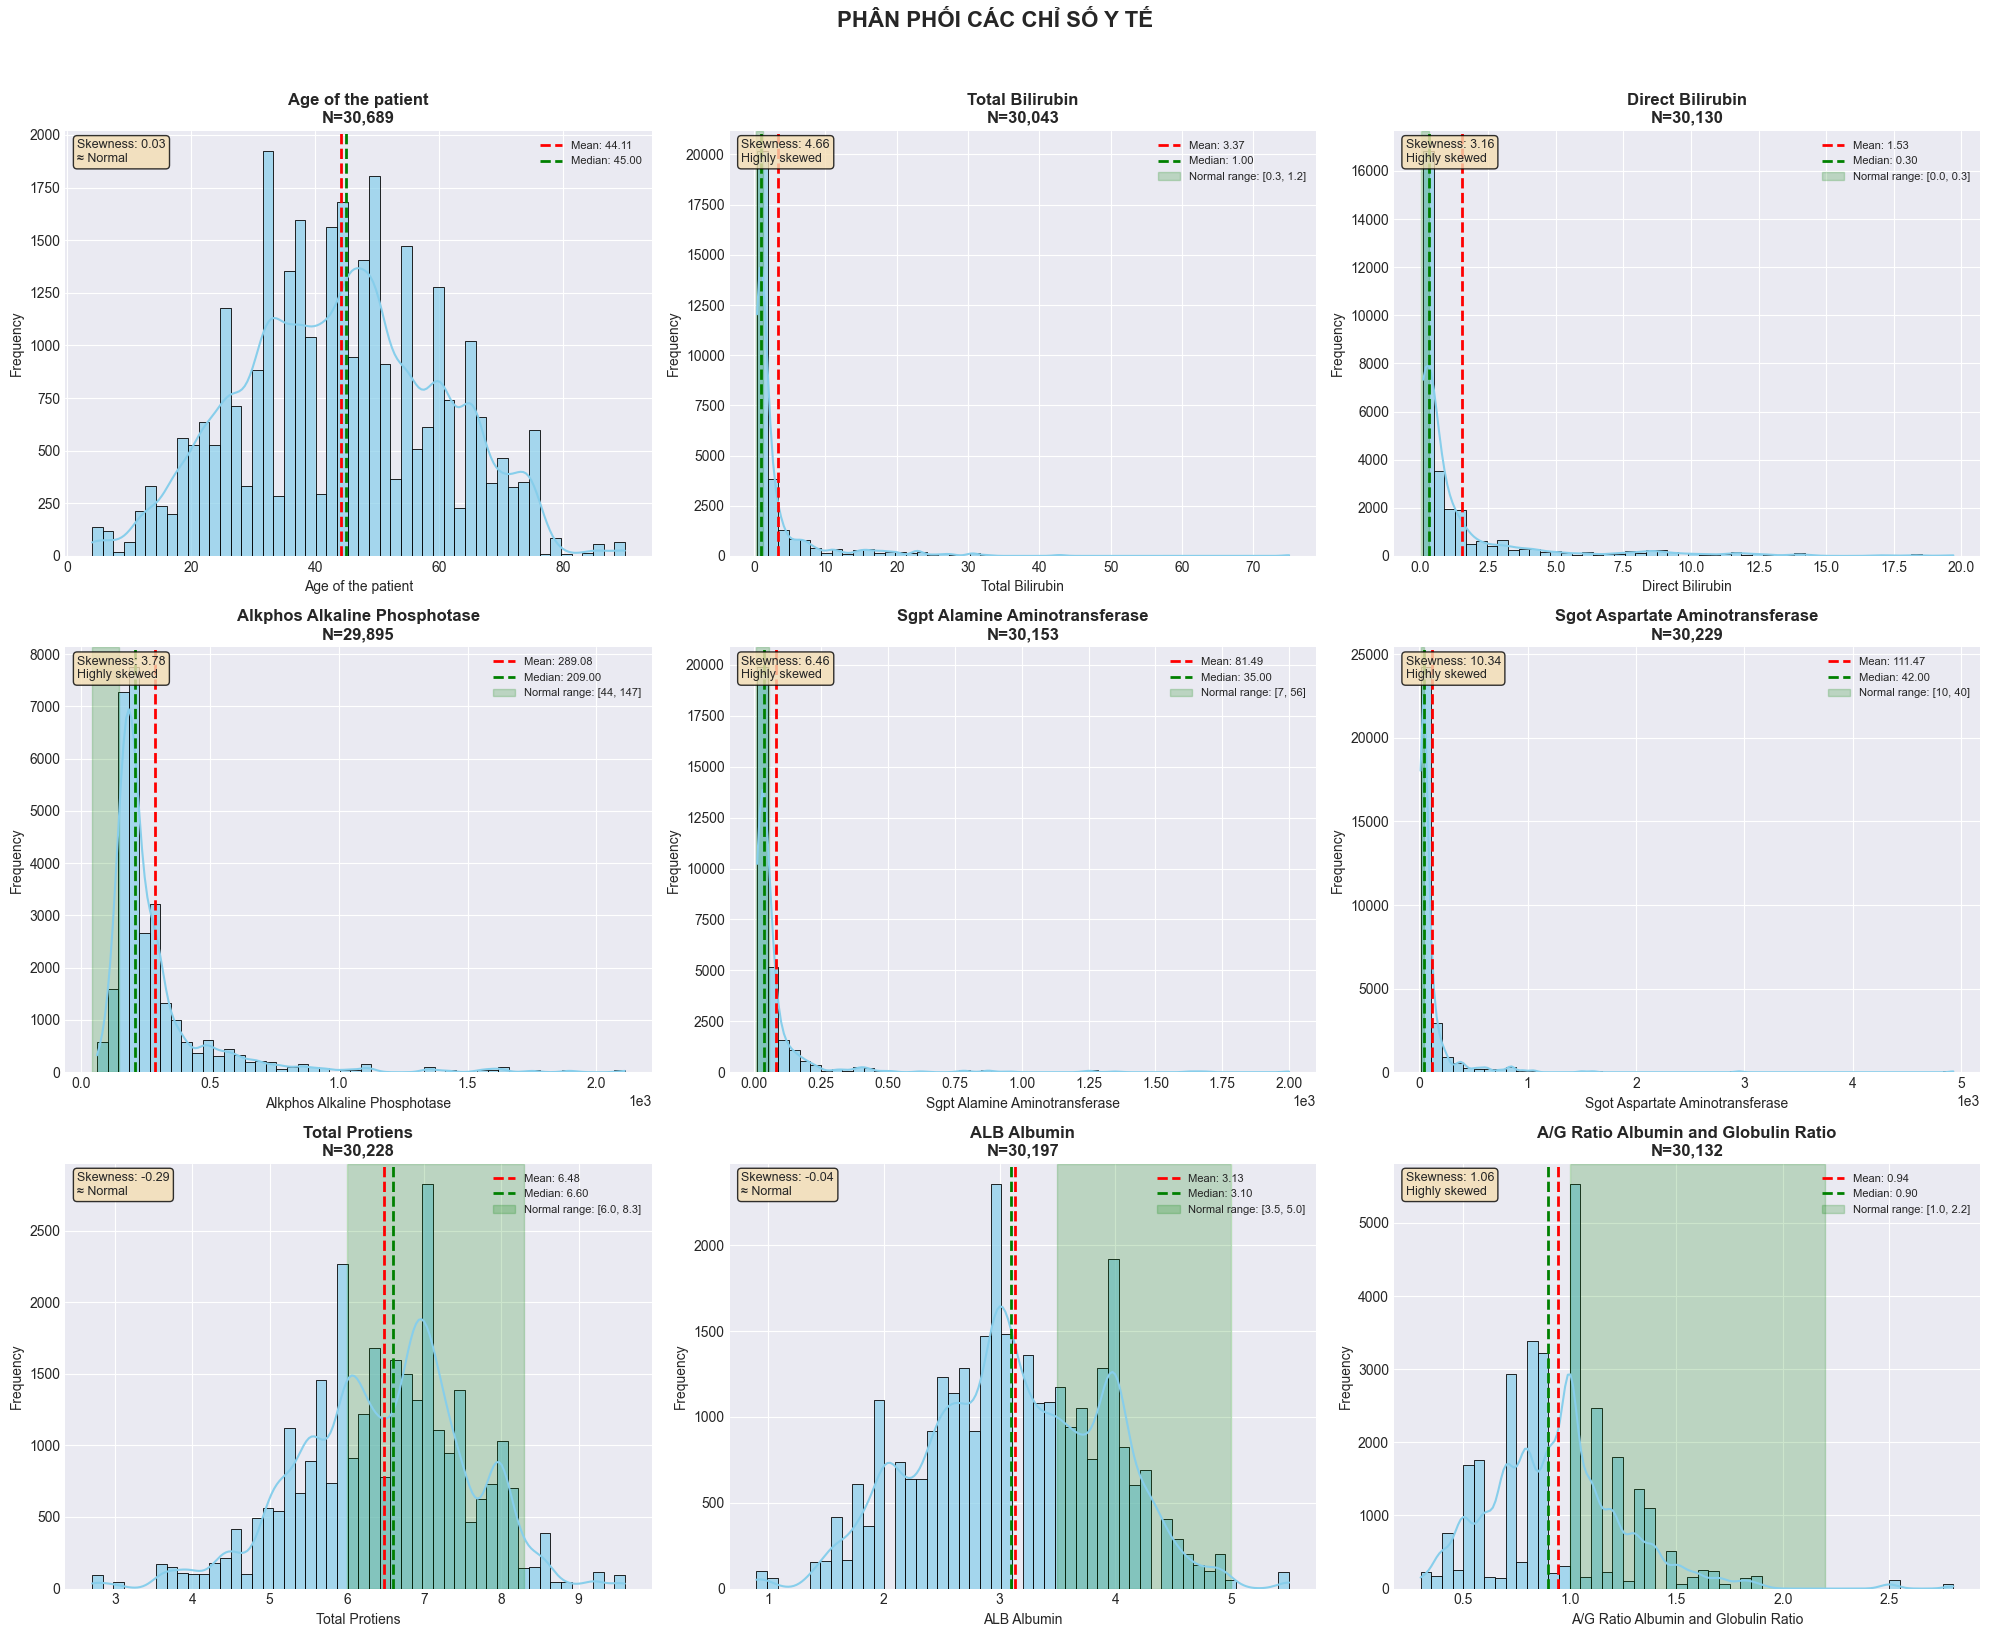

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

def visualize_medical_data(df, figsize=(20, 16)):
    """
    Vẽ biểu đồ toàn diện cho dữ liệu y tế
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame chứa dữ liệu y tế
    figsize : tuple
        Kích thước figure tổng
    """
    
    # Cài đặt style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Tạo figure lớn với nhiều subplots
    fig = plt.figure(figsize=figsize)
    
    # Danh sách các chỉ số cần visualize
    medical_columns = [
        'Age of the patient',
        'Total Bilirubin',
        'Direct Bilirubin',
        'Alkphos Alkaline Phosphotase',
        'Sgpt Alamine Aminotransferase',
        'Sgot Aspartate Aminotransferase',
        'Total Protiens',
        'ALB Albumin',
        'A/G Ratio Albumin and Globulin Ratio'
    ]
    
    # Lọc chỉ các cột có trong dataframe
    plot_columns = [col for col in medical_columns if col in df.columns]
    n_plots = len(plot_columns)
    
    # Tính layout
    n_rows = (n_plots + 2) // 3  # Làm tròn lên, tối đa 3 cột
    n_cols = min(3, n_plots)
    
    # Tiêu chuẩn y tế để so sánh
    medical_standards = {
        'Total Bilirubin': (0.3, 1.2),  # (min_normal, max_normal)
        'Direct Bilirubin': (0.0, 0.3),
        'Alkphos Alkaline Phosphotase': (44, 147),  # U/L cho người lớn
        'Sgpt Alamine Aminotransferase': (7, 56),   # U/L
        'Sgot Aspartate Aminotransferase': (10, 40), # U/L
        'Total Protiens': (6.0, 8.3),  # g/dL
        'ALB Albumin': (3.5, 5.0),     # g/dL
        'A/G Ratio Albumin and Globulin Ratio': (1.0, 2.2)
    }
    
    # Vẽ từng biểu đồ
    for idx, col in enumerate(plot_columns, 1):
        ax = plt.subplot(n_rows, n_cols, idx)
        
        # Kiểm tra dữ liệu
        data = df[col].dropna()
        if len(data) == 0:
            ax.text(0.5, 0.5, f'No data for {col}', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Vẽ histogram với KDE
        sns.histplot(data=data, kde=True, ax=ax, bins=50, 
                    color='skyblue', edgecolor='black', alpha=0.7)
        
        # Thêm đường thẳng cho mean, median
        mean_val = data.mean()
        median_val = data.median()
        
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                  label=f'Median: {median_val:.2f}')
        
        # Thêm vùng tiêu chuẩn y tế nếu có
        if col in medical_standards:
            normal_min, normal_max = medical_standards[col]
            ax.axvspan(normal_min, normal_max, alpha=0.2, color='green',
                      label=f'Normal range: [{normal_min}, {normal_max}]')
        
        # Tính và hiển thị skewness
        skewness = data.skew()
        skew_text = f'Skewness: {skewness:.2f}\n'
        if abs(skewness) < 0.5:
            skew_text += '≈ Normal'
        elif abs(skewness) < 1:
            skew_text += 'Moderately skewed'
        else:
            skew_text += 'Highly skewed'
        
        # Thêm text box với thông tin
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, skew_text, transform=ax.transAxes, fontsize=9,
               verticalalignment='top', bbox=props)
        
        # Cài đặt tiêu đề và labels
        ax.set_title(f'{col}\nN={len(data):,}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.legend(loc='upper right', fontsize=8)
        
        # Định dạng trục x cho số lớn
        if data.max() > 1000:
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    
    plt.suptitle('PHÂN PHỐI CÁC CHỈ SỐ Y TẾ', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig = visualize_medical_data(df)

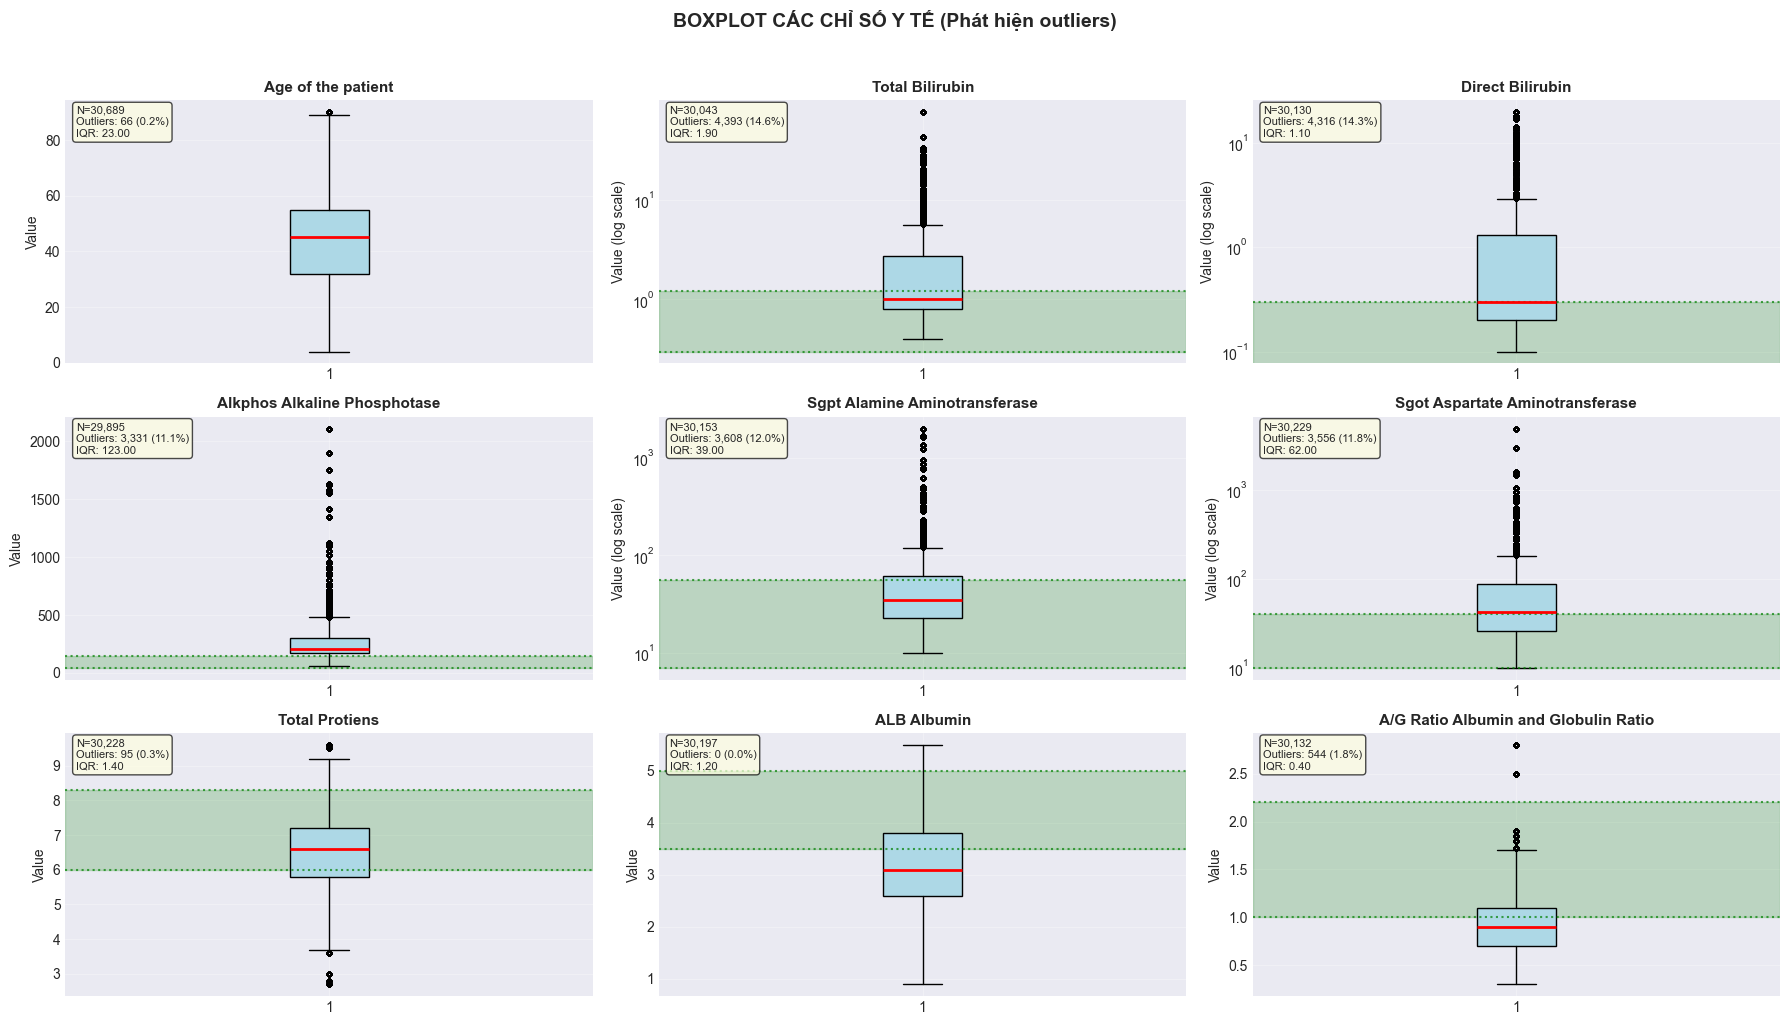

In [66]:
def plot_medical_boxplots(df, figsize=(18, 10)):
    """
    Vẽ boxplot cho tất cả chỉ số y tế
    """
    # Chọn các cột số
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Loại bỏ cột kết quả nếu có
    if 'Result' in numeric_cols:
        numeric_cols.remove('Result')
    if 'Gender of the patient' in numeric_cols:
        numeric_cols.remove('Gender of the patient')
    
    # Tính số lượng subplot
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    # Tiêu chuẩn y tế (màu xanh lá cho vùng bình thường)
    medical_standards = {
        'Total Bilirubin': (0.3, 1.2),
        'Direct Bilirubin': (0.0, 0.3),
        'Alkphos Alkaline Phosphotase': (44, 147),
        'Sgpt Alamine Aminotransferase': (7, 56),
        'Sgot Aspartate Aminotransferase': (10, 40),
        'Total Protiens': (6.0, 8.3),
        'ALB Albumin': (3.5, 5.0),
        'A/G Ratio Albumin and Globulin Ratio': (1.0, 2.2)
    }
    
    for idx, col in enumerate(numeric_cols):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        data = df[col].dropna()
        
        # Vẽ boxplot
        bp = ax.boxplot(data, vert=True, patch_artist=True, 
                       boxprops=dict(facecolor='lightblue'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markersize=3, alpha=0.5))
        
        # Thêm vùng tiêu chuẩn y tế
        if col in medical_standards:
            normal_min, normal_max = medical_standards[col]
            ax.axhspan(normal_min, normal_max, alpha=0.2, color='green')
            ax.axhline(normal_min, color='green', linestyle=':', alpha=0.7)
            ax.axhline(normal_max, color='green', linestyle=':', alpha=0.7)
        
        # Tính outliers
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_count = len(data[data > upper_bound])
        outliers_percent = (outliers_count / len(data)) * 100
        
        # Thêm thông tin
        info_text = f"N={len(data):,}\n"
        info_text += f"Outliers: {outliers_count:,} ({outliers_percent:.1f}%)\n"
        info_text += f"IQR: {IQR:.2f}"
        
        props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.7)
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=8,
               verticalalignment='top', bbox=props)
        
        # Cài đặt đồ thị
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Log scale nếu dữ liệu spread quá lớn
        if data.max() / data.median() > 20 and data.median() > 0:
            ax.set_yscale('log')
            ax.set_ylabel('Value (log scale)')
    
    # Ẩn các axes không sử dụng
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('BOXPLOT CÁC CHỈ SỐ Y TẾ (Phát hiện outliers)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig2 = plot_medical_boxplots(df)

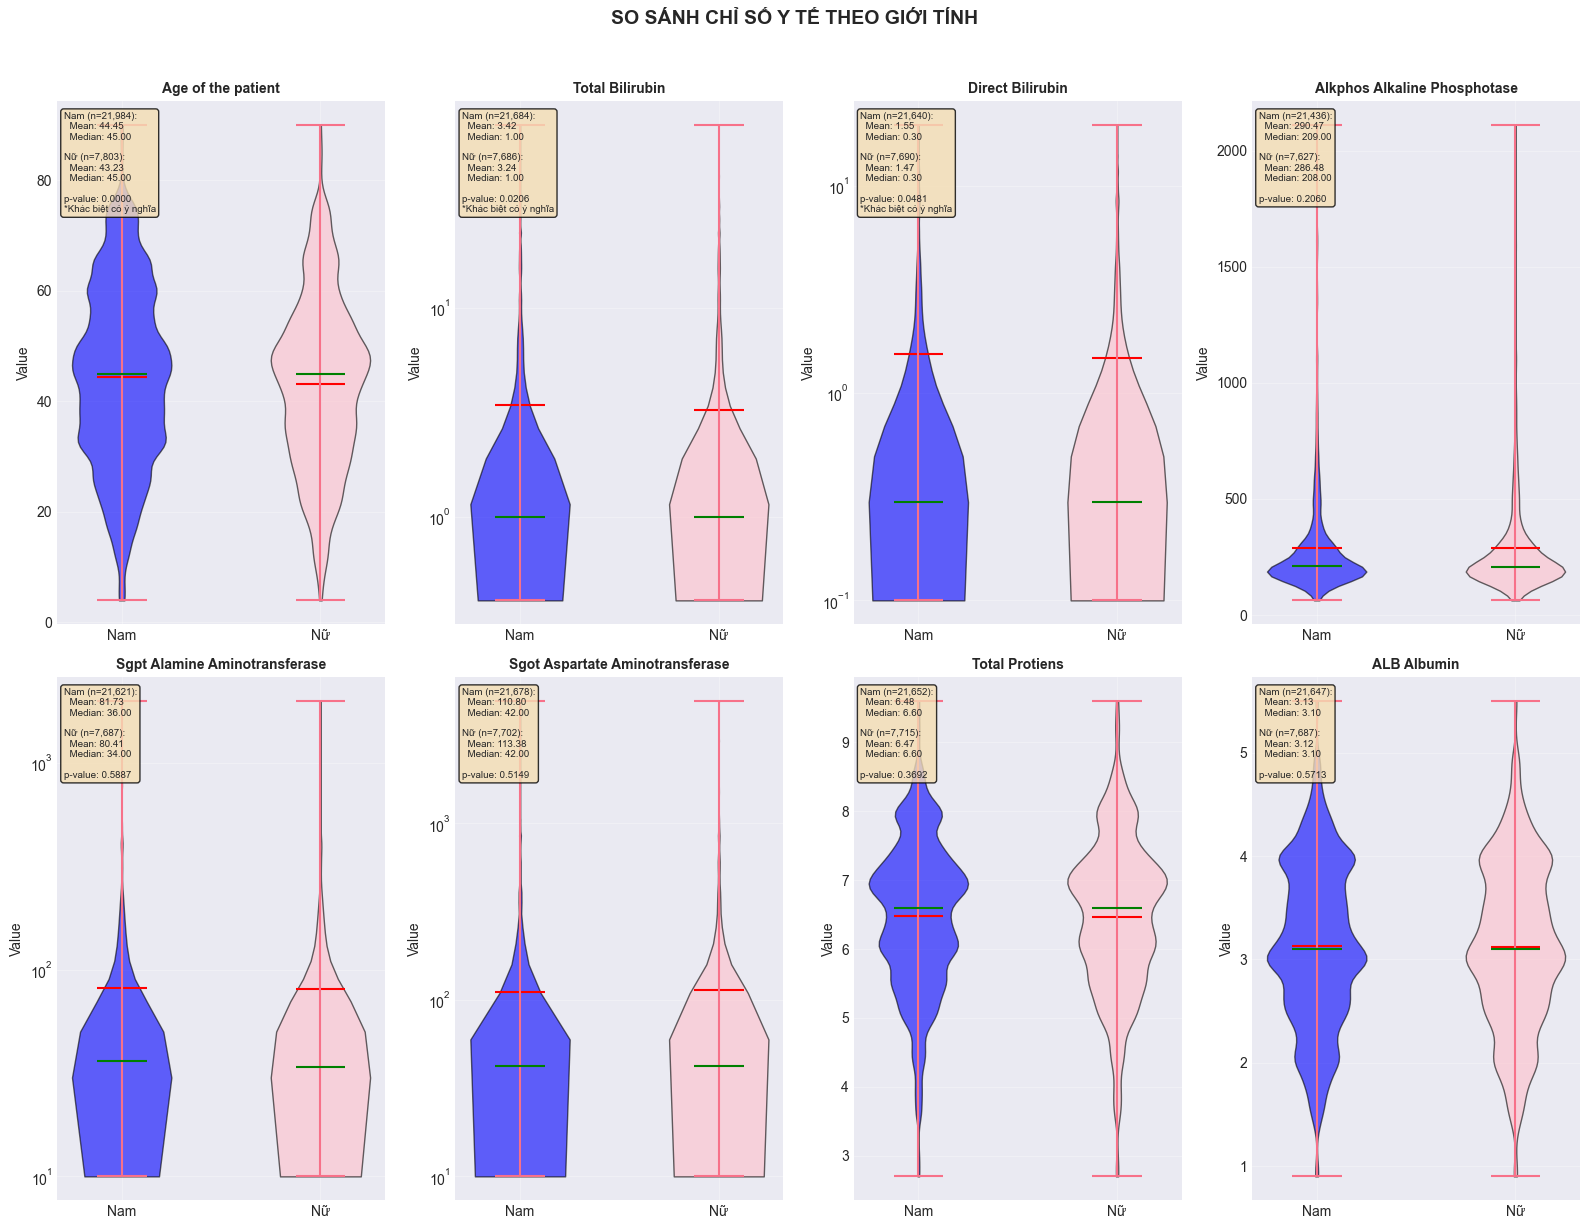

In [67]:
def plot_by_gender(df, figsize=(16, 12)):
    """
    Vẽ biểu đồ so sánh theo giới tính
    """
    if 'Gender of the patient' not in df.columns:
        print("Không tìm thấy cột giới tính")
        return
    
    # Chọn các cột y tế chính
    medical_cols = [
        'Age of the patient',
        'Total Bilirubin',
        'Direct Bilirubin',
        'Alkphos Alkaline Phosphotase',
        'Sgpt Alamine Aminotransferase',
        'Sgot Aspartate Aminotransferase',
        'Total Protiens',
        'ALB Albumin'
    ]
    
    # Lọc các cột có trong dataframe
    plot_cols = [col for col in medical_cols if col in df.columns]
    
    # Tạo figure
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()
    
    # Màu cho nam/nữ
    colors = {1: 'blue', 2: 'pink'}  # 1=nam, 2=nữ
    gender_labels = {1: 'Nam', 2: 'Nữ'}
    
    for idx, col in enumerate(plot_cols):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        
        # Dữ liệu theo giới tính
        data_male = df[df['Gender of the patient'] == 1][col].dropna()
        data_female = df[df['Gender of the patient'] == 2][col].dropna()
        
        # Kiểm tra có dữ liệu không
        if len(data_male) == 0 or len(data_female) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            continue
        
        # Vẽ violin plot
        violin_parts = ax.violinplot(
            [data_male, data_female],
            showmeans=True,
            showmedians=True
        )
        
        # Tô màu cho violin plot
        for pc, gender in zip(violin_parts['bodies'], [1, 2]):
            pc.set_facecolor(colors[gender])
            pc.set_alpha(0.6)
            pc.set_edgecolor('black')
        
        # Đặt màu cho mean và median
        violin_parts['cmeans'].set_color('red')
        violin_parts['cmedians'].set_color('green')
        
        # Tính toán thống kê
        stats_text = f"Nam (n={len(data_male):,}):\n"
        stats_text += f"  Mean: {data_male.mean():.2f}\n"
        stats_text += f"  Median: {data_male.median():.2f}\n\n"
        stats_text += f"Nữ (n={len(data_female):,}):\n"
        stats_text += f"  Mean: {data_female.mean():.2f}\n"
        stats_text += f"  Median: {data_female.median():.2f}"
        
        # Kiểm tra sự khác biệt (t-test)
        if len(data_male) > 30 and len(data_female) > 30:
            t_stat, p_value = stats.ttest_ind(data_male, data_female, equal_var=False)
            stats_text += f"\n\np-value: {p_value:.4f}"
            if p_value < 0.05:
                stats_text += "\n*Khác biệt có ý nghĩa"
        
        # Thêm thông tin thống kê
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=7,
               verticalalignment='top', bbox=props)
        
        # Cài đặt đồ thị
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Nam', 'Nữ'])
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Log scale nếu cần
        max_val = max(data_male.max(), data_female.max())
        median_val = max(data_male.median(), data_female.median())
        if max_val / median_val > 50 and median_val > 0:
            ax.set_yscale('log')
    
    # Ẩn axes không sử dụng
    for idx in range(len(plot_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('SO SÁNH CHỈ SỐ Y TẾ THEO GIỚI TÍNH', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig3 = plot_by_gender(df)

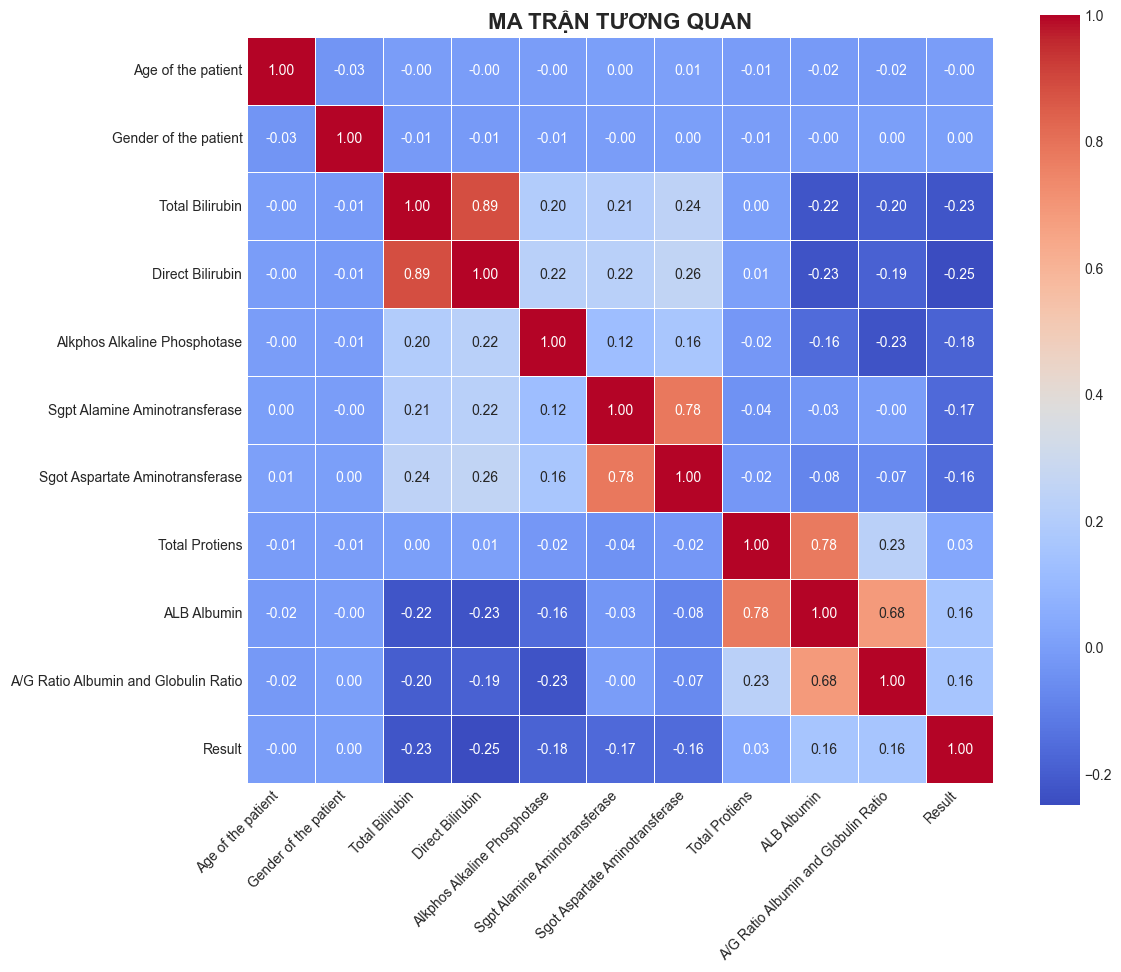

In [68]:
# Chỉ lấy cột số
numeric_df = df.select_dtypes(include=[np.number])

# Tính ma trận correlation
corr_matrix = numeric_df.corr()

# Vẽ heatmap ĐƠN GIẢN
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm",
            fmt=".2f",
            square=True,
            linewidths=0.5)

plt.title('MA TRẬN TƯƠNG QUAN', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\nahno\AppData\Local\Temp\ipykernel_11768\3489898710.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df_age.groupby('Age Group')[col].agg(['mean', 'std', 'count'])
C:\Users\nahno\AppData\Local\Temp\ipykernel_11768\3489898710.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df_age.groupby('Age Group')[col].agg(['mean', 'std', 'count'])
C:\Users\nahno\AppData\Local\Temp\ipykernel_11768\3489898710.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob

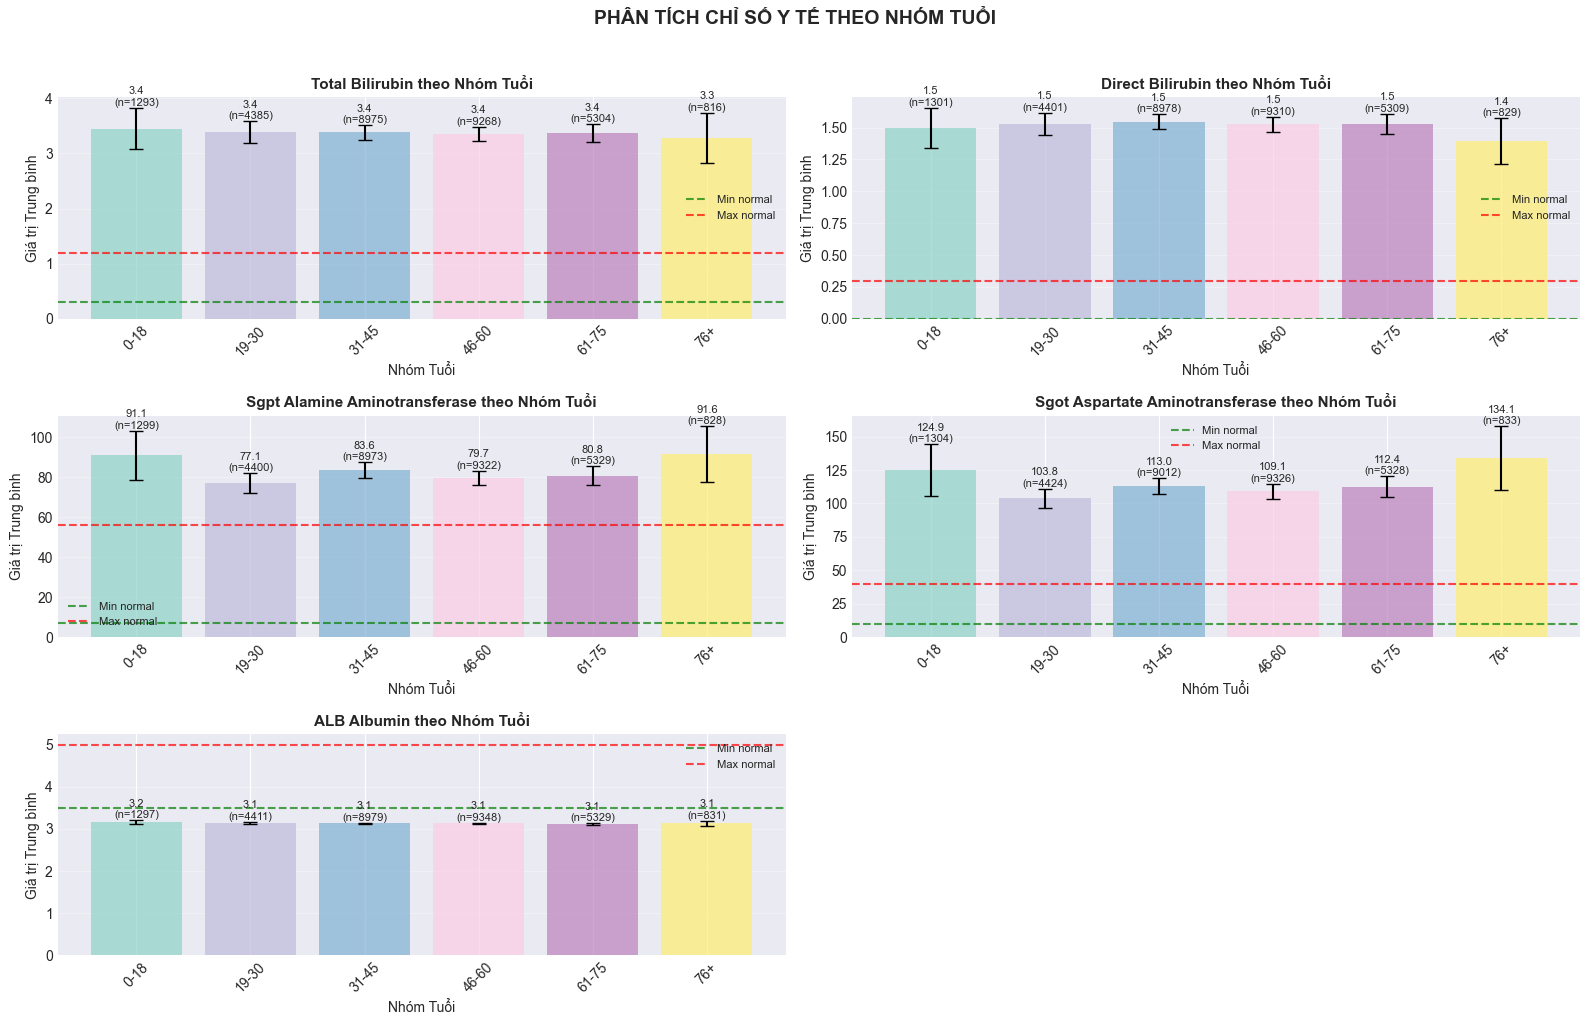

In [69]:
def plot_by_age_groups(df, figsize=(16, 10)):
    """
    Vẽ biểu đồ phân tích theo nhóm tuổi
    """
    if 'Age of the patient' not in df.columns:
        print("Không tìm thấy cột tuổi")
        return
    
    # Tạo nhóm tuổi
    bins = [0, 18, 30, 45, 60, 75, 100]
    labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76+']
    
    df_age = df.copy()
    df_age['Age Group'] = pd.cut(df_age['Age of the patient'], 
                                 bins=bins, labels=labels, right=False)
    
    # Chọn các chỉ số cần phân tích
    medical_cols = [
        'Total Bilirubin',
        'Direct Bilirubin',
        'Sgpt Alamine Aminotransferase',
        'Sgot Aspartate Aminotransferase',
        'ALB Albumin'
    ]
    
    plot_cols = [col for col in medical_cols if col in df.columns]
    
    # Tạo figure
    n_cols = 2
    n_rows = (len(plot_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(plot_cols):
        ax = axes[idx]
        
        # Vẽ bar plot với error bars
        age_stats = df_age.groupby('Age Group')[col].agg(['mean', 'std', 'count'])
        
        # Tính confidence interval (95%)
        age_stats['ci'] = 1.96 * age_stats['std'] / np.sqrt(age_stats['count'])
        
        # Vẽ bar plot
        x_pos = np.arange(len(age_stats))
        bars = ax.bar(x_pos, age_stats['mean'], 
                     yerr=age_stats['ci'],
                     capsize=5, alpha=0.7,
                     color=plt.cm.Set3(np.linspace(0, 1, len(age_stats))))
        
        # Thêm số liệu trên mỗi bar
        for i, (mean_val, count_val) in enumerate(zip(age_stats['mean'], age_stats['count'])):
            ax.text(i, mean_val + age_stats['ci'].iloc[i], 
                   f'{mean_val:.1f}\n(n={int(count_val)})',
                   ha='center', va='bottom', fontsize=8)
        
        # Cài đặt đồ thị
        ax.set_title(f'{col} theo Nhóm Tuổi', fontsize=11, fontweight='bold')
        ax.set_xlabel('Nhóm Tuổi')
        ax.set_ylabel('Giá trị Trung bình')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(age_stats.index, rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Thêm đường tiêu chuẩn y tế nếu có
        medical_standards = {
            'Total Bilirubin': (0.3, 1.2),
            'Direct Bilirubin': (0.0, 0.3),
            'Sgpt Alamine Aminotransferase': (7, 56),
            'Sgot Aspartate Aminotransferase': (10, 40),
            'ALB Albumin': (3.5, 5.0)
        }
        
        if col in medical_standards:
            normal_min, normal_max = medical_standards[col]
            ax.axhline(normal_min, color='green', linestyle='--', alpha=0.7, label=f'Min normal')
            ax.axhline(normal_max, color='red', linestyle='--', alpha=0.7, label=f'Max normal')
            ax.legend(fontsize=8)
    
    # Ẩn axes không sử dụng
    for idx in range(len(plot_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('PHÂN TÍCH CHỈ SỐ Y TẾ THEO NHÓM TUỔI', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Sử dụng:
fig5 = plot_by_age_groups(df)

#### 3. Tiền xử lý dữ liệu

In [70]:
#Chiến lược: xóa các bộ có giá trị null
df_cleaned = df.dropna()
print(f"Số dòng ban đầu: {len(df)}")
print(f"Số dòng sau khi xóa null: {len(df_cleaned)}")
print(f"Đã xóa: {len(df) - len(df_cleaned)} dòng")
df = df_cleaned

Số dòng ban đầu: 30691
Số dòng sau khi xóa null: 27158
Đã xóa: 3533 dòng


In [71]:
#nhận thấy: từ biểu đồ cool hot warm gì đấy, có biến Total Bilirubin và Direct Bilirubin có độ tương quan tới 0.89.
#Mà đối với KNN, khi 2 biến quá giống nhau, chúng sẽ làm nhiễu mô hình KNN, giống như kiểu một thông tin bị tính tới 2 lần trong hàm khoảng cách
#Chúng ta có 2 phương án, hoặc là bỏ đi biến direct Bilirubin vì total Bilirubin đã bao gồm direct Bilirubin rồi, hoặc là chỉnh sửa lại trọng
#số trong mô hình KNN
def remove_column(df, column_name):
    if column_name not in df.columns:
        print(f"cột {column_name} không tồn tại trong data Frame")
        return df
    df_new = df.copy()
    df_new = df_new.drop(columns=[column_name])
    print(f"Đã xóa cột {column_name}")
    return df_new


In [72]:
#Xử lý outliner: sử dụng log transform
# Dữ liệu gốc:
# - SGPT: từ 10 đến 2000 (chênh lệch 200 lần!)
# - SGOT: từ 10 đến 4929 (chênh lệch 493 lần!)
# - Alkphos: từ 63 đến 2110
# → Khoảng cách quá lớn gây vấn đề cho KNN!

def log_transform(df, column_name):
    if column_name not in df.columns:
        print(f"cột {column_name} không tồn tại trong data Frame")
        return df
    df_new = df.copy()
    df_new[column_name] = np.log1p(df_new[column_name])
    print(f"Đã log transform cột {column_name}")
    return df_new

df = log_transform(df,"Sgpt Alamine Aminotransferase")
df = log_transform(df,"Sgot Aspartate Aminotransferase")
df = log_transform(df,"Alkphos Alkaline Phosphotase")

Đã log transform cột Sgpt Alamine Aminotransferase
Đã log transform cột Sgot Aspartate Aminotransferase
Đã log transform cột Alkphos Alkaline Phosphotase


In [73]:
from sklearn.discriminant_analysis import StandardScaler


from sklearn.preprocessing import StandardScaler

# Tách feature và nhãn
feature_cols = [c for c in df.columns if c != 'Result']
X = df[feature_cols]
y = df['Result']

# Chuẩn hóa feature số (đã gồm cột giới tính dạng 1/2)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols,
    index=df.index
)

# Ghép lại với nhãn
df = pd.concat([X_scaled, y], axis=1)
df.head()

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,1.307032,1.676957,-0.427630,-0.497967,-0.502027,-1.084783,-1.072939,0.302735,0.222078,-0.134383,1
1,1.119194,-0.596318,1.183142,1.367298,2.010369,0.430670,0.615820,0.950010,0.095865,-0.627908,1
2,1.119194,-0.596318,0.614634,0.883711,1.332626,0.358903,0.230684,0.487671,0.222078,-0.165229,1
3,0.868745,-0.596318,-0.380254,-0.394341,-0.553542,-1.226211,-0.971772,0.302735,0.348290,0.174070,1
4,1.745319,-0.596318,0.077710,0.158330,-0.422386,-0.520951,0.089409,0.765074,-0.913835,-1.676648,1
